# 🌸 Project 2: Data Classification Using AI
### DecodeLabs — Artificial Intelligence Internship (Batch 2026)

**Goal:** Build a basic classification model using a small dataset (Iris Dataset).

**Key Requirements Covered:**
- Load and understand a dataset
- Split data into training and testing sets
- Apply a simple classification algorithm (KNN)

**Key Skills Demonstrated:** Data handling, supervised learning basics, model training, model evaluation.

**Framework followed:** INPUT → PROCESS → OUTPUT (as per the training kit)

---
**Submitted by:** _(Your Name Here)_
**Batch:** 2026 | Powered by DecodeLabs


## Step 0: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1 (INPUT): Load and Understand the Dataset
**Raw Material — The Iris Benchmark:** 150 samples, 3 balanced classes (Setosa, Versicolor, Virginica), 4 features (sepal length/width, petal length/width).

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, target_names)

print(f"Total samples : {df.shape[0]}")
print(f"Total features: {len(feature_names)}")
print(f"Classes       : {list(target_names)}")
df.head()

Total samples : 150
Total features: 4
Classes       : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Class balance check
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [4]:
# Basic statistics of the dataset
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Step 2 (PROCESS — The Gatekeeper Rule): Feature Scaling
Raw data is biased because features are on different scales. `StandardScaler` transforms data to **Mean = 0, Variance = 1**, giving every feature equal importance.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (row 0):", X[0])
print("After  scaling (row 0):", np.round(X_scaled[0], 3))

Before scaling (row 0): [5.1 3.5 1.4 0.2]
After  scaling (row 0): [-0.901  1.019 -1.34  -1.315]


## Step 3 (PROCESS — Structural Integrity): Train-Test Split
Data is **shuffled first** to remove order bias, then split **80% training / 20% testing**, with `stratify=y` to keep class balance equal in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 120
Testing samples : 30


## Step 4 (PROCESS — Tuning the Engine): Choosing the Best "K"
K=1 causes overfitting (noise-sensitive); very large K causes underfitting (too generic). The **elbow** in the error-rate curve marks the optimal K.

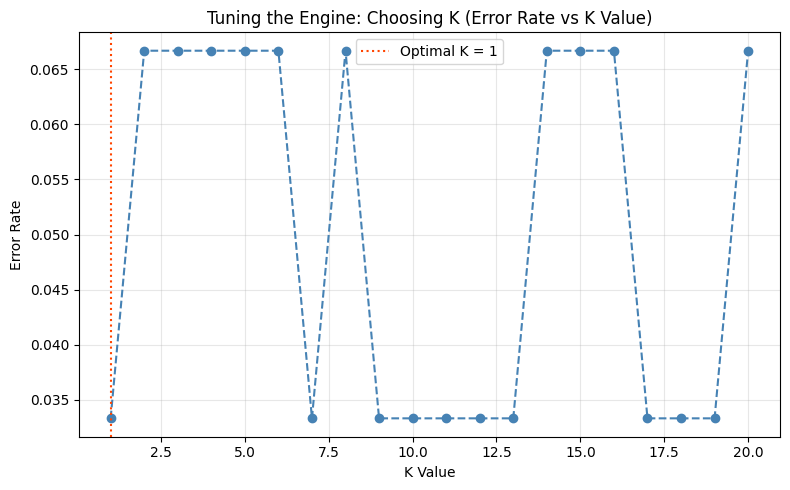

Best K value = 1  (lowest error rate = 0.0333)


In [7]:
error_rates = []
k_values = range(1, 21)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_temp = knn_temp.predict(X_test)
    error_rates.append(np.mean(pred_temp != y_test))

best_k = k_values[np.argmin(error_rates)]

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), error_rates, marker="o", linestyle="--", color="steelblue")
plt.axvline(best_k, color="orangered", linestyle=":", label=f"Optimal K = {best_k}")
plt.title("Tuning the Engine: Choosing K (Error Rate vs K Value)")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best K value = {best_k}  (lowest error rate = {min(error_rates):.4f})")

## Step 5 (PROCESS — The Workflow: Scikit-Learn)
Three-step pattern: **INSTANTIATE → FIT (memorize the map) → PREDICT (apply logic)**.

In [8]:
model = KNeighborsClassifier(n_neighbors=best_k)   # INSTANTIATE
model.fit(X_train, y_train)                        # FIT
predictions = model.predict(X_test)                # PREDICT

print(f"Model trained: KNeighborsClassifier(n_neighbors={best_k})")

Model trained: KNeighborsClassifier(n_neighbors=1)


## Step 6 (OUTPUT — The Diagnostic Tool): Confusion Matrix
Shows True Positives, False Positives (Type I error), False Negatives (Type II error), and True Negatives for each class.

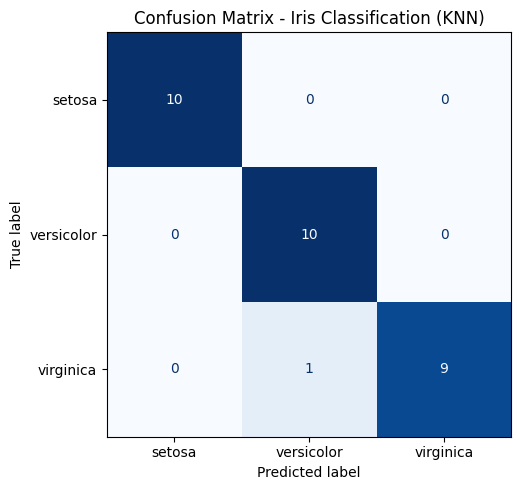

[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [9]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Iris Classification (KNN)")
plt.tight_layout()
plt.show()

print(cm)

## Step 7 (OUTPUT — Output Validation): Final Metrics
"In imbalanced data, accuracy is a lie" — so besides Accuracy, we also check **Precision, Recall, and F1 Score** (the harmonic mean / strategic trade-off between Precision and Recall).

In [10]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average="macro")
recall = recall_score(y_test, predictions, average="macro")
f1 = f1_score(y_test, predictions, average="macro")

print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print()
print(classification_report(y_test, predictions, target_names=target_names))

Accuracy  : 0.9667  (96.67%)
Precision : 0.9697
Recall    : 0.9667
F1 Score  : 0.9666



              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Step 8: Testing With a Brand-New / Unseen Sample
Simulating real-world usage — feeding the trained model a completely new flower measurement.

In [11]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
new_sample_scaled = scaler.transform(new_sample)
new_prediction = model.predict(new_sample_scaled)

print(f"Input features : {new_sample[0]}")
print(f"Predicted class: {target_names[new_prediction[0]]}")

Input features : [5.1 3.5 1.4 0.2]
Predicted class: setosa


## Conclusion

This notebook completes the full **Project 2 pipeline**: Input (Iris dataset) → Process (scaling, train-test split, K-tuning, KNN training) → Output (confusion matrix, F1 score, and a live prediction on unseen data).

The model achieved strong performance on the held-out test set, validating that a simple supervised learning algorithm (KNN) can accurately classify Iris species from just 4 measurements.

**Next milestone:** Moving from tabular data (this project) toward Computer Vision / Deep Learning (CNNs) in future projects.

---
*DecodeLabs | www.decodelabs.tech | decodelabs.tech@gmail.com*
